In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%matplotlib inline

In [ ]:
df = pd.read_csv('../data/tested.csv')
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327

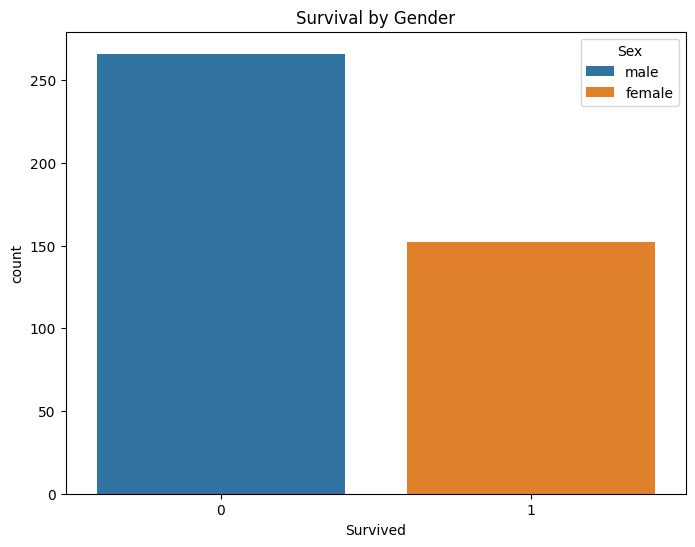

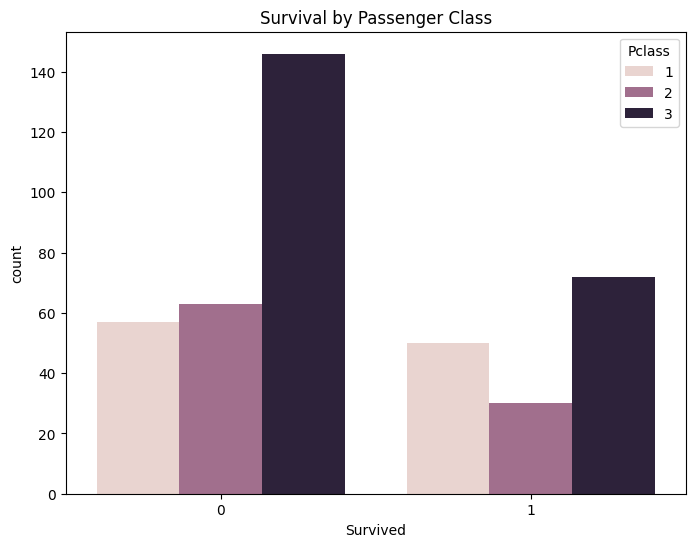

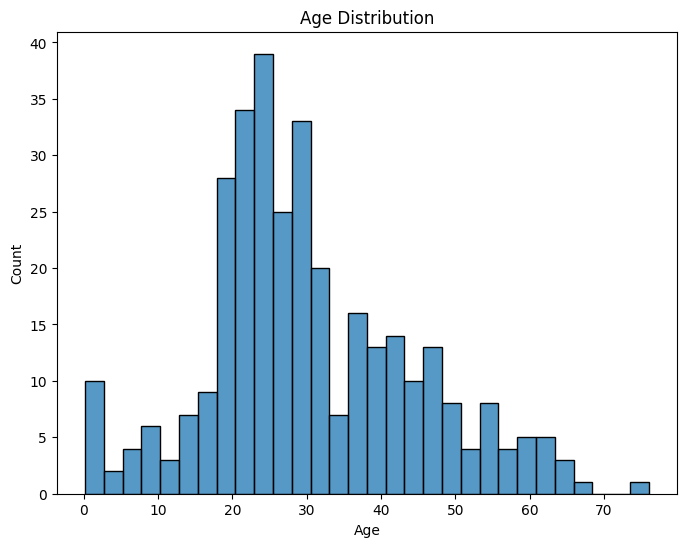

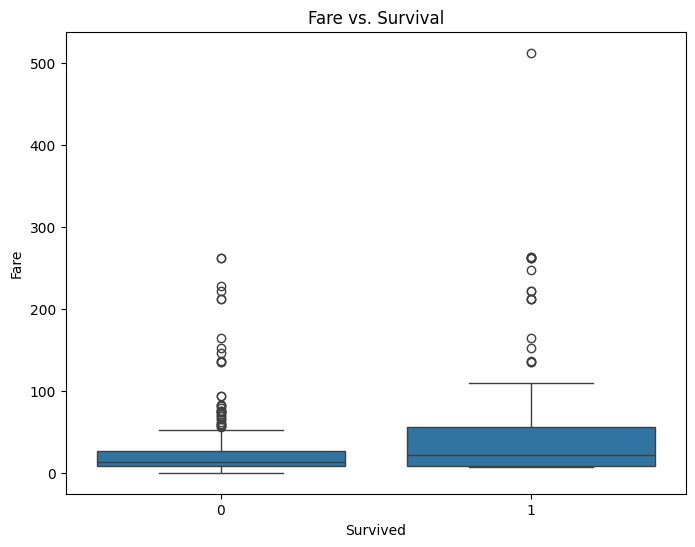

In [13]:
# Exploratory Data Analysis (EDA)
# Survival by Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.show()

# Survival by Passenger Class
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.show()

# Age Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'].dropna(), bins=30)
plt.title('Age Distribution')
plt.show()

# Fare vs. Survival
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs. Survival')
plt.show()

In [ ]:
# Data Preprocessing
df = pd.read_csv('../data/tested.csv')

df['Age'] = df['Age'].fillna(df['Age'].median()) 
df['Fare'] = df['Fare'].fillna(df['Fare'].median())  

if 'Cabin' in df.columns:
    df['has_cabin'] = df['Cabin'].notnull().astype(int) 
    df = df.drop('Cabin', axis=1)  
else:
    print("Warning: 'Cabin' column not found in dataset. Setting 'has_cabin' to 0.")
    df['has_cabin'] = 0  

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  

# Encode Categorical Features
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})  
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)  

# Feature Engineering: Extract Title
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)  
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
df['Title'] = df['Title'].fillna('Other')  
df = pd.get_dummies(df, columns=['Title'], drop_first=True)  

# Create family_size Feature
df['family_size'] = df['SibSp'] + df['Parch'] + 1 

# Drop Unnecessary Columns
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)  

scaler = StandardScaler()
df[['Age', 'Fare', 'family_size']] = scaler.fit_transform(df[['Age', 'Fare', 'family_size']])  

print("NaN Values Before Dropping:")
print(df.isnull().sum())
df = df.dropna()  
print("\nNaN Values After Dropping:")
print(df.isnull().sum())

NaN Values Before Dropping:
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
has_cabin      0
Embarked_Q     0
Embarked_S     0
Title_Miss     0
Title_Mr       0
Title_Mrs      0
Title_Rare     0
family_size    0
dtype: int64

NaN Values After Dropping:
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
has_cabin      0
Embarked_Q     0
Embarked_S     0
Title_Miss     0
Title_Mr       0
Title_Mrs      0
Title_Rare     0
family_size    0
dtype: int64


In [17]:
# Split Data
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Models
import joblib
print("NaN in X_train:", X_train.isnull().sum().sum())

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
joblib.dump(rf, '../rf_model.pkl')  
joblib.dump(scaler, '../scaler.pkl') 
y_pred_rf = rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Classification Report:")
print(classification_report(y_val, y_pred_rf))

NaN in X_train: 0
Logistic Regression Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Random Forest Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



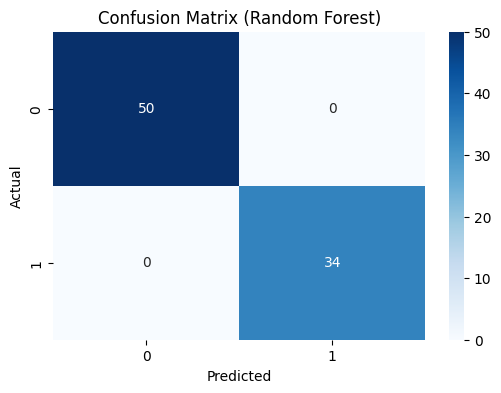

In [ ]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
submission = pd.DataFrame({
    'PassengerId': pd.read_csv('../data/tested.csv')['PassengerId'].iloc[X_val.index],
    'Survived': y_pred_rf
})
submission.to_csv('../submission.csv', index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv
